Images: 118
Neurons: 39209
Animate fraction: 0.5338983050847458
Bottom 6 indices: [ 46  30   4   0  61 116]
Top 6 indices: [ 19 101   9  25  85  29]


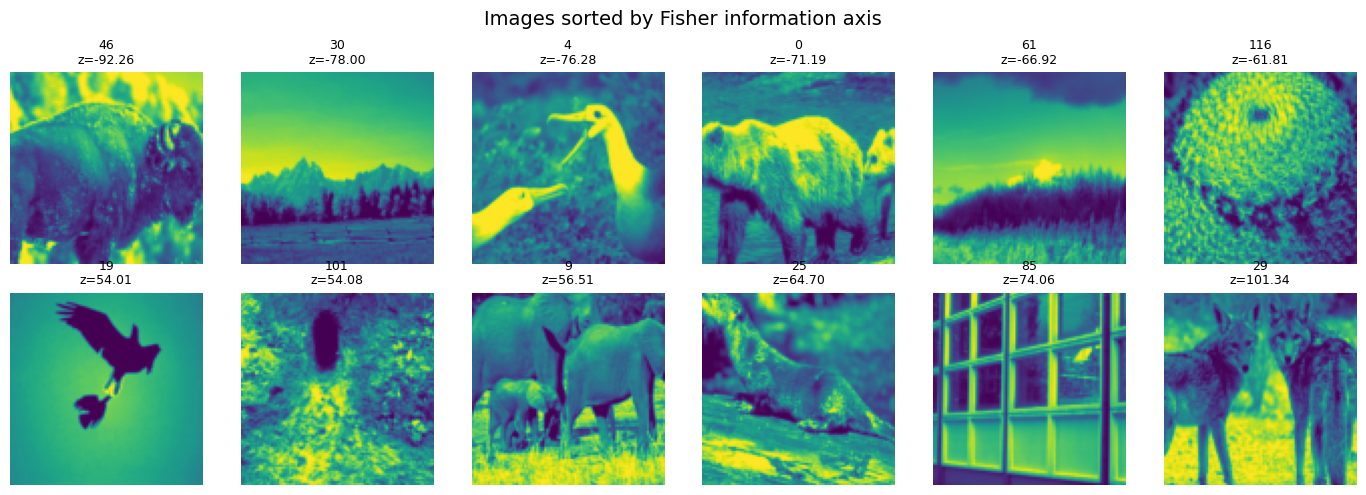

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ============================================================
# PATHS
# ============================================================

VIT_PATH    = '/home/maria/ProjectionSort/data/google_vit-base-patch16-224_embeddings_logits.pkl'
NEURAL_PATH = '/home/maria/ProjectionSort/data/hybrid_neural_responses_reduced.npy'
IMAGE_DIR   = '/home/maria/ProjectionSort/data/images/images'

# ============================================================
# LOAD DATA
# ============================================================

vit = np.load(VIT_PATH, allow_pickle=True)['natural_scenes']   # (images, 1000)
X   = np.load(NEURAL_PATH).T.astype(float)                     # (images, neurons)

print("Images:", X.shape[0])
print("Neurons:", X.shape[1])

# Animate / inanimate labels
top1 = np.argmax(vit, axis=1)
y = (top1 <= 397).astype(int)

print("Animate fraction:", y.mean())

# ============================================================
# STANDARDIZE (important)
# ============================================================

scaler = StandardScaler(with_mean=True, with_std=True)
Xz = scaler.fit_transform(X)

# ============================================================
# FIT LOGISTIC REGRESSION
# ============================================================

clf = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=2000
)
clf.fit(Xz, y)

p = clf.predict_proba(Xz)[:, 1]
w = p * (1 - p)     # Fisher weights, shape (images,)

# ============================================================
# POWER ITERATION FOR TOP FISHER EIGENVECTOR
# ============================================================

def fisher_matvec(v):
    """
    Computes I v = X^T ( W (X v) )
    without forming I.
    """
    Xv = Xz @ v                  # (images,)
    return Xz.T @ (w * Xv)       # (neurons,)

# Initialize random vector in neuron space
rng = np.random.default_rng(0)
v = rng.normal(size=Xz.shape[1])
v /= np.linalg.norm(v)

# Power iterations
N_ITER = 50
for _ in range(N_ITER):
    v = fisher_matvec(v)
    v /= np.linalg.norm(v)

u1 = v   # top Fisher eigenvector (unit norm)

# ============================================================
# PROJECT POPULATION VECTORS
# ============================================================

z = Xz @ u1
order = np.argsort(z)

bottom_idx = order[:6]
top_idx    = order[-6:]

print("Bottom 6 indices:", bottom_idx)
print("Top 6 indices:", top_idx)

# ============================================================
# PLOT IMAGES
# ============================================================

def load_image(idx):
    fname = f"scene_{idx:03d}.png"
    return plt.imread(os.path.join(IMAGE_DIR, fname))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for j, idx in enumerate(bottom_idx):
    axes[0, j].imshow(load_image(idx))
    axes[0, j].axis('off')
    axes[0, j].set_title(f"{idx}\nz={z[idx]:.2f}", fontsize=9)

for j, idx in enumerate(top_idx):
    axes[1, j].imshow(load_image(idx))
    axes[1, j].axis('off')
    axes[1, j].set_title(f"{idx}\nz={z[idx]:.2f}", fontsize=9)

axes[0, 0].set_ylabel("Bottom Fisher axis", fontsize=12)
axes[1, 0].set_ylabel("Top Fisher axis", fontsize=12)

plt.suptitle("Images sorted by Fisher information axis", fontsize=14)
plt.tight_layout()
plt.show()
